# Pretrained SpecFormer, and what its embeddings retrieve

Loads the released spectrum encoder of AstroCLIP
([Parker et al. 2024, MNRAS 531:4990](https://doi.org/10.1093/mnras/stae1450))
from [`polymathic-ai/astroclip`](https://huggingface.co/polymathic-ai/astroclip)
via `astrospec.pretrained.load_pretrained_specformer`, which loads the checkpoint's
spectrum tower only, loaded into `astrospec.models.specformer.SpecFormer`
directly. AstroCLIP itself is a cross-modal image+spectrum contrastive model;
this notebook does not build or use that model, only the spectral half of it.

It then uses the pretrained embeddings for cosine nearest-neighbour retrieval,
the same evaluation `specformer_pretraining.ipynb` runs after training
`SpecFormer` from scratch. No training happens here: the model already saw far
more than the ~16,000 spectra and 45 epochs of that notebook's toy run, and the
retrieval below should read as measurably tighter than the from-scratch
embeddings for the same reason.

The data path is `utils/sdss.py`, as in the other notebooks: a local
MultimodalUniverse HDF5 copy if `ASTROSPEC_SDSS_ROOT` is set, otherwise
streaming [`MultimodalUniverse/sdss`](https://huggingface.co/datasets/MultimodalUniverse/sdss)
from the Hub.

## Install example-only dependencies

Not part of AstroSpec's core install; only needed for this example.

In [1]:
!pip install -q "astrospec[pretrained]" h5py datasets matplotlib

## Imports

In [2]:
import numpy as np
import torch
import torch.nn.functional as F

from astrospec.data import Patchify
from astrospec.pretrained import load_pretrained_specformer
from utils import sdss

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the pretrained spectrum encoder

Downloads AstroCLIP's released checkpoint once (cached by `huggingface_hub`
afterwards) and loads only the `spectrum_encoder.backbone.*` weights into
`astrospec.models.specformer.SpecFormer`, with no Lightning, dinov2, or the
`astroclip` package involved, since the spectrum tower already lives natively
in this library.

In [3]:
model = load_pretrained_specformer(device=device)
sum(p.numel() for p in model.parameters())

/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


43177750

## Load spectra and cut them into patches

2,000 held-out spectra with their pipeline redshifts, no train/val split is
needed since the model is not trained here. SpecFormer takes 22 numbers per
patch: the 20-pixel patch standardized by its own mean and standard deviation,
with those two statistics appended, as in `specformer_pretraining.ipynb`.

In [4]:
flux, z = sdss.load_spectra(2000, redshift=True)
flux = sdss.standardize(flux)

patchify = Patchify(patch_size=20)
patches, valid = patchify(torch.from_numpy(flux))

def to_tokens(patches):
    mean = patches.mean(-1, keepdim=True)
    std = patches.std(-1, keepdim=True).clamp_min(1e-6)
    return torch.cat([(patches - mean) / std, mean, std], dim=-1)

tokens = to_tokens(patches)
tokens.shape, valid.shape

(torch.Size([2000, 193, 22]), torch.Size([2000, 193]))

## Embed and search for nearest neighbours

Mean-pool the valid tokens of `forward_features` into one vector per spectrum,
center by the set mean (raw cosine similarities otherwise all sit above 0.999,
as in the from-scratch notebook), then rank by cosine similarity. Redshift,
which the model never sees, checks whether nearby embeddings are physically
similar; random pairs are the baseline.

In [5]:
@torch.no_grad()
def embed(batch_tokens, batch_valid):
    out = []
    for i in range(0, len(batch_tokens), 64):
        t = batch_tokens[i : i + 64].to(device)
        v = batch_valid[i : i + 64].to(device)
        features = model.forward_features(t, valid=v)
        pooled = (features * v.unsqueeze(-1)).sum(1) / v.sum(1, keepdim=True)
        out.append(pooled.cpu())
    return torch.cat(out)

pooled = embed(tokens, valid)
embeddings = F.normalize(pooled - pooled.mean(0, keepdim=True), dim=-1)

similarity = embeddings @ embeddings.T
similarity.fill_diagonal_(-1)
best = similarity.max(-1)
neighbour, neighbour_score = best.indices.numpy(), best.values.numpy()

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(z))
random_score = (embeddings * embeddings[shuffled]).sum(-1).numpy()

print(f"{'':>17}  {'cosine':>8}  {'median |dz|':>12}  {'|dz| < 0.01':>12}")
for name, score, delta in [
    ("nearest neighbour", neighbour_score, np.abs(z - z[neighbour])),
    ("random pair", random_score, np.abs(z - z[shuffled])),
]:
    print(
        f"{name:>17}  {np.median(score):8.3f}  {np.median(delta):12.4f}"
        f"  {(delta < 0.01).mean():11.1%}"
    )

                     cosine   median |dz|   |dz| < 0.01
nearest neighbour     0.760        0.0452        27.7%
      random pair     0.008        0.0924        10.0%


## A query and its three nearest neighbours

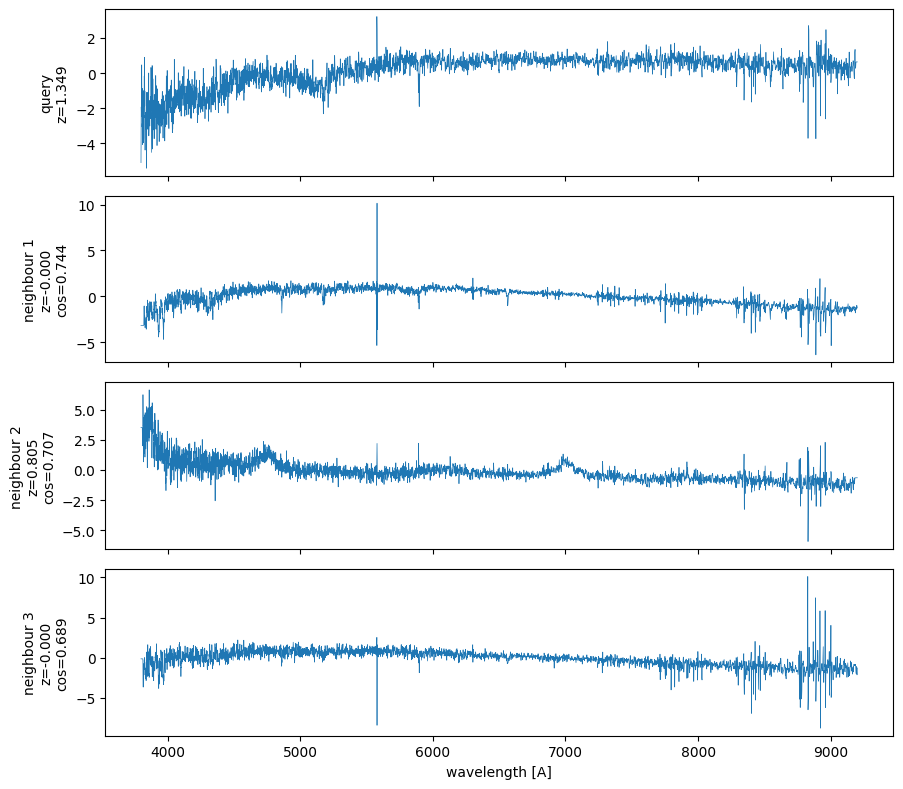

In [6]:
import matplotlib.pyplot as plt

query = int(np.argmax(z > 0.3))
top = similarity[query].topk(3)
panels = [(query, "query", None)] + [
    (int(i), f"neighbour {k + 1}", float(s))
    for k, (i, s) in enumerate(zip(top.indices, top.values))
]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (i, title, score) in zip(axes, panels):
    ax.plot(sdss.COMMON_GRID, flux[i], lw=0.5)
    label = f"{title}\nz={z[i]:.3f}"
    ax.set_ylabel(label if score is None else f"{label}\ncos={score:.3f}")
axes[-1].set_xlabel("wavelength [A]")
fig.tight_layout()

## Notes

`load_pretrained_specformer` returns the same `SpecFormer` class the rest of
the library uses, so anything written against a from-scratch model: a pooling
head, a downstream task, `forward_features` itself, works unchanged against
the pretrained one. Compare this notebook's retrieval numbers against
`specformer_pretraining.ipynb`'s: the pretrained encoder was never limited to
16,000 spectra or 45 epochs, so its neighbours should sit at higher cosine
similarity and lower median `|dz|` for the same task.